# 2.3 RNA-protein integration with GLUE

## Workflow outline
1. Load the Hammond RNA reference and final SCP protein object.
2. Reprocess the RNA reference and evaluate batch structure.
3. Train scVI/scANVI embeddings for the RNA subset.
4. Build a shared RNA-protein guidance graph and train GLUE.
5. Transfer labels and inspect the joint embedding.


## Setup
Imports, plotting defaults, multi-omics packages, and project paths.


In [2]:
# import packages
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')

import warnings
warnings.filterwarnings('ignore')

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

import networkx as nx
import scglue
# import scvi

# set data and figure dir
data_dir = '/Volumes/SU700/scpMS_data/scpMS_microglia/scRNA-seq/'
fig_dir = 'SCP_Microglia/figures/2_3_glue/'
results_dir = 'SCP_Microglia/results/2_3_glue/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

sc.settings.verbosity = 3

In [3]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

### mRNA-Protein Disorder

## Load RNA and protein inputs
Read the Hammond RNA reference and final SCP protein object.


In [29]:
hammond_rna = sc.read_h5ad(data_dir + 'Hammond_et-al-2019_Aged.h5ad')
adata_scp = sc.read_h5ad('SCP_Microglia/results/1_5_clustering/scp_MG_1c_maxlfq_final_version.h5ad')

### Process Hammond et al. data
This work use a ICA based method to remove batch effect. While in 2019, Harmony and scVI haven't been proposed, we choose to use scVI instead of ICA to reanalyze this data, which is more robust.

In [2]:
hammond_rna = sc.read_h5ad(data_dir + 'Hammond_et-al-2019_Aged.h5ad')

In [3]:
hammond_rna

AnnData object with n_obs × n_vars = 14866 × 16626
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents'
    var: 'names'
    obsm: 'X_tsne'
    layers: 'counts', 'data'

In [4]:
print(hammond_rna.obs['sample'].value_counts())
print(hammond_rna.obs['cluster_name'].value_counts())

sample
Old_male_4     2604
Old_male_3     2520
P100_male_7    2253
P100_male_6    2093
P100_Male_4    1927
P100_Male_5    1557
Old_male_1     1099
Old_male_2      813
Name: count, dtype: int64
cluster_name
OA1a        6271
OA1b        5936
OA3         1538
OA2          655
Mono/Mac     466
Name: count, dtype: int64


## RNA preprocessing
Filter, normalize, select HVGs, and inspect RNA batch structure.


In [5]:
hammond_rna.X = hammond_rna.layers['counts'].copy()

# reanalyze the raw data with scVI methods, normalized dataset isn't used for downstream analysis
del hammond_rna.layers['data']

In [6]:
sc.pp.filter_cells(hammond_rna, min_genes=200)
sc.pp.filter_genes(hammond_rna, min_cells=3)

filtered out 2308 genes that are detected in less than 3 cells


In [7]:
sc.pp.normalize_total(hammond_rna)
sc.pp.log1p(hammond_rna, base=2)

normalizing counts per cell
    finished (0:00:00)


In [8]:
sc.pp.highly_variable_genes(
    hammond_rna,
    n_top_genes=3000,
    flavor='seurat_v3',
    layer='counts',
    batch_key='sample',
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [9]:
# look at batch effects
sc.tl.pca(hammond_rna, n_comps=50, svd_solver='arpack', use_highly_variable=True)
sc.pp.neighbors(hammond_rna, n_neighbors=20)
sc.tl.umap(hammond_rna, min_dist=0.3, spread=1.0)

computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


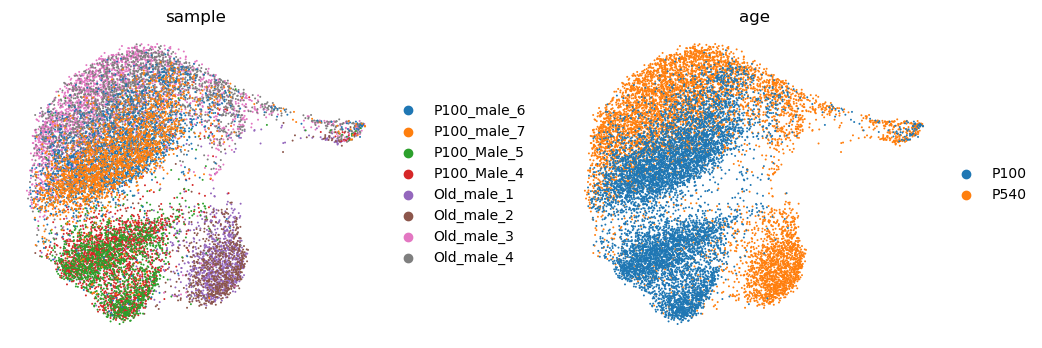

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, metric in enumerate(['sample', 'age']):
    sc.pl.umap(
        hammond_rna,
        color=metric,
        wspace=0.3,
        ncols=2,
        frameon=False,
        show=False,
        ax=axes[i],
    )
plt.subplots_adjust(wspace=0.5)
plt.savefig(fig_dir + 'Hammond_raw_umap.pdf', dpi=300, bbox_inches='tight')

In [ ]:
adata_scp = sc.read_h5ad('SCP_Microglia/results/1_5_clustering/scp_MG_1c_maxlfq_final_version.h5ad')

## Shared feature selection
Retain RNA genes needed for the GLUE graph and SCP overlap.


In [14]:
hammond_rna.var['in_protein'] = hammond_rna.var_names.isin(adata_scp.var_names)
hammond_rna_subset = hammond_rna[:, (hammond_rna.var['in_protein']) | (hammond_rna.var['highly_variable'])]

In [15]:
hammond_rna_subset

View of AnnData object with n_obs × n_vars = 14866 × 5928
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents', 'n_genes'
    var: 'names', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'in_protein'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'sample_colors', 'age_colors'
    obsm: 'X_tsne', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [16]:
hammond_rna_subset.write_h5ad(results_dir + 'Hammond_et-al-2019_Aged_preprocessed_for_glue.h5ad', compression='gzip')

#### Use scVI to correct batch

In [17]:
hammond_rna_subset = sc.read_h5ad(results_dir + 'Hammond_et-al-2019_Aged_preprocessed_for_glue.h5ad')

# we substract hvgs to run scVI
hammond_rna_subset = hammond_rna_subset[:, hammond_rna_subset.var['highly_variable']].copy()

In [18]:
hammond_rna_subset

AnnData object with n_obs × n_vars = 14866 × 3000
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents', 'n_genes'
    var: 'names', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'in_protein'
    uns: 'age_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [19]:
from lightning.pytorch.loggers import TensorBoardLogger

tensorboard_logger_scVI = TensorBoardLogger(
    save_dir="SCP_Microglial/results/logs",
    name="scvi_hammond_rna_subset"
)

scvi.model.SCVI.setup_anndata(
    hammond_rna_subset, 
    layer='counts', 
    batch_key='sample'
)

scvi_model = scvi.model.SCVI(
    hammond_rna_subset, 
    n_latent=20,
    n_layers=2,
    gene_likelihood='nb'
)

scvi_model.train(
    batch_size=1024,
    early_stopping=True,
    logger=[tensorboard_logger_scVI],
    max_epochs=500,
)

scvi_model.save(results_dir + 'scVI_model_Hammond', overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 440/500:  88%|████████▊ | 440/500 [05:41<00:46,  1.29it/s, v_num=0, train_loss=647]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 662.864. Signaling Trainer to stop.


#### Also we test scANVI

In [20]:
# we set up scANVI using trained scVI model
tensorboard_logger_scANVI = TensorBoardLogger(
    save_dir="SCP_Microglial/results/logs",
    name="scANVI_hammond_rna_subset"
)

scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata = hammond_rna_subset,
    unlabeled_category='Unknown',
    labels_key='cluster_name'
)

scanvi_model.train(
    batch_size=1024,
    early_stopping=True,
    logger=[tensorboard_logger_scANVI],
    max_epochs=100,
    n_samples_per_label=200
)

scanvi_model.save(results_dir + 'scANVI_model_Hammond', overwrite=True)

INFO     Training for 100 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 46/100:  46%|████▌     | 46/100 [00:58<01:08,  1.27s/it, v_num=0, train_loss=632]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 659.450. Signaling Trainer to stop.


In [23]:
hammond_rna_subset.obsm['X_scVI'] = scvi_model.get_latent_representation()
hammond_rna_subset.obsm['X_scANVI'] = scanvi_model.get_latent_representation()

In [24]:
hammond_rna_subset
# adata‘X is log2_total_normalized_raw_counts

AnnData object with n_obs × n_vars = 14866 × 3000
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents', 'n_genes', '_scvi_batch', '_scvi_labels'
    var: 'names', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'in_protein'
    uns: 'age_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_scVI', 'X_scANVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [25]:
hammond_palettes = ["#CCCCCC", "#B3B3B3", "#0000CD", "#00CDCD", "#000000"]

# set hammond cluster_name's order
cluster_order = ['OA1a', 'OA1b', 'OA2', 'OA3', 'Mono/Mac']

hammond_rna_subset.obs['cluster_name'] = hammond_rna_subset.obs['cluster_name'].astype('category')
hammond_rna_subset.obs['cluster_name'].cat.set_categories(cluster_order)

hammond_rna_subset.uns['cluster_name_colors'] = hammond_palettes

In [35]:
hammond_rna_subset_raw = sc.read_h5ad(results_dir + 'Hammond_et-al-2019_Aged_preprocessed_for_glue.h5ad')

hammond_rna_subset_raw.obsm['X_scANVI'] = scanvi_model.get_latent_representation()
hammond_rna_subset_raw.obsm['X_scVI'] = scvi_model.get_latent_representation()

In [ ]:
hammond_rna_subset_raw.write_h5ad(results_dir + 'Hammond_et-al-2019_Aged_preprocessed_for_glue.h5ad', compression='gzip')

In [4]:
hammond_rna = sc.read_h5ad(results_dir + 'Hammond_et-al-2019_Aged_preprocessed_for_glue.h5ad')

In [5]:
sc.tl.tsne(hammond_rna, use_rep='X_scVI', random_state=0)
hammond_rna.obsm['X_tsne_scVI'] = hammond_rna.obsm['X_tsne']

sc.tl.tsne(hammond_rna, use_rep='X_scANVI', random_state=0)
hammond_rna.obsm['X_tsne_scANVI'] = hammond_rna.obsm['X_tsne']

computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:22)
computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:24)


In [6]:
hammond_rna

AnnData object with n_obs × n_vars = 14866 × 5928
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents', 'n_genes'
    var: 'names', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'in_protein'
    uns: 'age_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap', 'tsne'
    obsm: 'X_pca', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'X_tsne_scVI', 'X_tsne_scANVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [5]:
del hammond_rna.obsm['X_tsne']

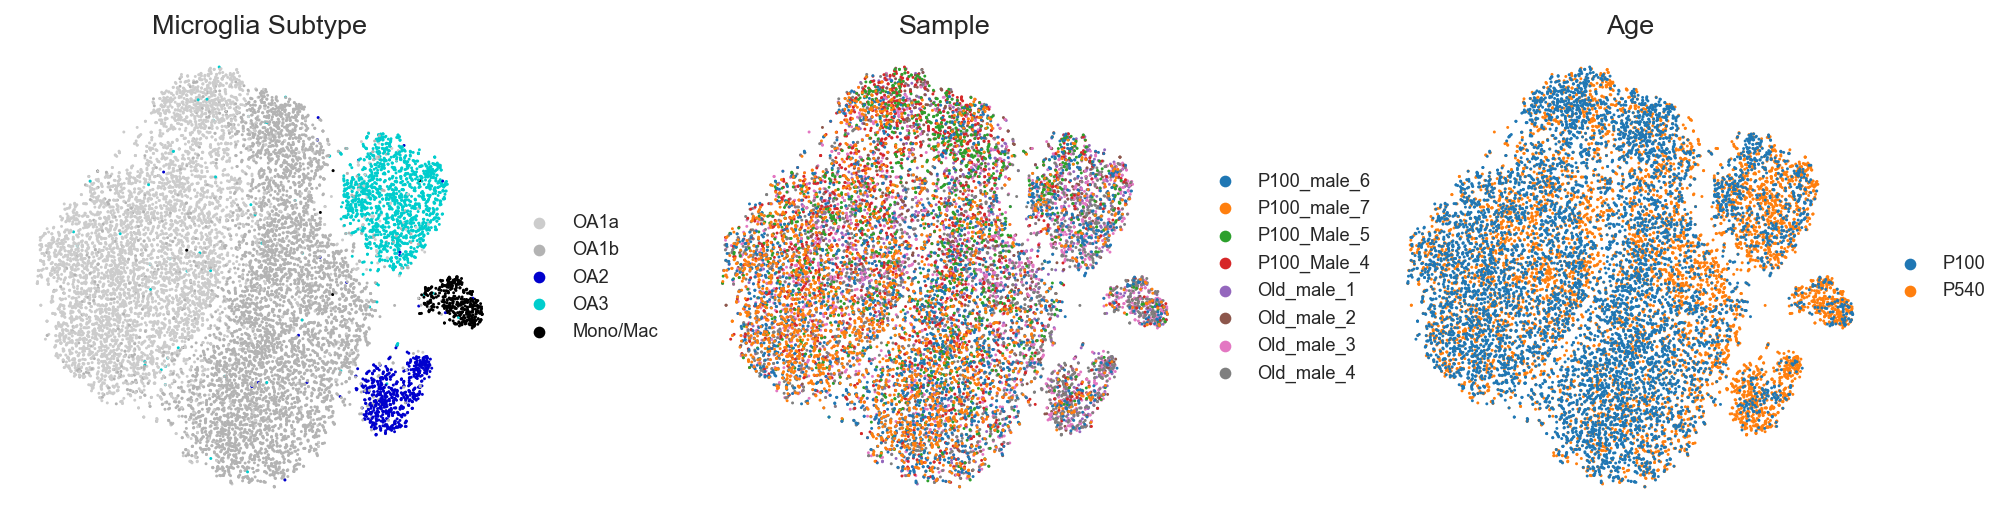

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
for i, parameter in enumerate(['cluster_name', 'sample', 'age']):
    sc.pl.embedding(
        hammond_rna,
        basis='X_tsne_scANVI',
        color=parameter,
        frameon=False,
        ax=ax[i],
        show=False,
        palette= ["#CCCCCC", "#B3B3B3", "#0000CD", "#00CDCD", "#000000"] if parameter == 'cluster_name' else None,
        title=None,
    )
    ax[0].set_title('Microglia Subtype', fontsize=13)
    ax[1].set_title('Sample', fontsize=13)
    ax[2].set_title('Age', fontsize=13)
plt.subplots_adjust(wspace=0.4)
plt.savefig(fig_dir + 'hamsmond_rna_tsne_scANVI_embedding.pdf', bbox_inches='tight', dpi=300)

### Use GLUE to create the linked embedding

In [7]:
rna_glue = sc.read_h5ad(results_dir + 'Hammond_et-al-2019_Aged_preprocessed_for_glue.h5ad')
scp_glue = sc.read_h5ad('SCP_Microglia/results/1_5_clustering/scp_MG_1c_maxlfq_final_version.h5ad')

In [3]:
rna_glue

AnnData object with n_obs × n_vars = 14866 × 5928
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents', 'n_genes'
    var: 'names', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'in_protein'
    uns: 'age_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
print(len(rna_glue.var_names.intersection(scp_glue.var_names)))
print(len(scp_glue.var_names))

3506
3979


## GLUE graph and model training
Build the modality graph, configure GLUE, train the model, and save embeddings.


In [8]:
# --- 2. Graph Construction for GLUE ---
# Rename variables to distinguish modalities in the graph
# Appending suffixes '_rna' and '_scp'
intersect_genes = set(rna_glue.var_names).intersection(set(scp_glue.var_names))

rna_glue.var_names = [f"{x}_rna" for x in rna_glue.var_names]
scp_glue.var_names = [f"{x}_scp" for x in scp_glue.var_names]

# Create edges for the guidance graph
guidance_edges = []

# Edges between RNA and SCP for the same gene
for gene in intersect_genes:
    guidance_edges.append((f"{gene}_rna", f"{gene}_scp", {'weight': 0.9, 'sign': 1}))

# Self-loops for all features
for feature in rna_glue.var_names:
    guidance_edges.append((feature, feature, {'weight': 1.0, 'sign': 1}))
for feature in scp_glue.var_names:
    guidance_edges.append((feature, feature, {'weight': 1.0, 'sign': 1}))

# Build the NetworkX graph
guidance_graph = nx.Graph()
guidance_graph.add_nodes_from(rna_glue.var_names)
guidance_graph.add_nodes_from(scp_glue.var_names)
guidance_graph.add_edges_from(guidance_edges)

for _, e in zip(range(5), guidance_graph.edges):
    print(f"{e}: {guidance_graph.edges[e]}")

('X0610011F06Rik_rna', 'X0610011F06Rik_rna'): {'weight': 1.0, 'sign': 1}
('X0610039K10Rik_rna', 'X0610039K10Rik_rna'): {'weight': 1.0, 'sign': 1}
('X1110002L01Rik_rna', 'X1110002L01Rik_rna'): {'weight': 1.0, 'sign': 1}
('X1110008P14Rik_rna', 'X1110008P14Rik_rna'): {'weight': 1.0, 'sign': 1}
('X1110065P20Rik_rna', 'X1110065P20Rik_rna'): {'weight': 1.0, 'sign': 1}


In [7]:
print(len(guidance_graph.nodes), len(guidance_graph.edges))

9907 13413


In [ ]:
# finally no scale
# sc.pp.scale(scp_glue)

In [6]:
# --- 3. Configure and Train GLUE Model ---
# Configure RNA dataset
# Using 'NB' (Negative Binomial) distribution which is standard for scRNA-seq counts.
# We check if 'counts' layer is available, otherwise fallback to X (and maybe change to Normal if X is normalized).
scglue.models.configure_dataset(
    rna_glue, 
    "NB", 
    use_highly_variable=False,
    use_layer="counts",
    use_batch='sample',
    use_rep='X_scANVI',
)

# Configure SCP dataset
# Using 'Normal' distribution for proteomics/intensity data.
# scp_glue's X is scaled
scglue.models.configure_dataset(
    scp_glue, 
    "Normal", 
    use_highly_variable=False,
    use_batch='prepare_date',
    use_rep='CCA',
)

In [ ]:
glue_model = scglue.models.SCGLUEModel(
    {"rna": rna_glue, "scp": scp_glue},
    sorted(guidance_graph.nodes),
    random_seed=42,
    latent_dim=20,
)

[INFO] autodevice: Using GPU 0 as computation device.


In [9]:
glue_model.compile()
glue_model.fit({"rna": rna_glue, "scp": scp_glue}, guidance_graph,  data_batch_size=512)

[WARNING] SCGLUEModel: `compile` has already been called. Previous trainer will be overwritten!


[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!
[INFO] SCGLUEModel: Setting `graph_batch_size` = 5575
[INFO] SCGLUEModel: Setting `align_burnin` = 127
[INFO] SCGLUEModel: Setting `max_epochs` = 762
[INFO] SCGLUEModel: Setting `patience` = 64
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 32
[INFO] SCGLUETrainer: Using training directory: "/tmp/GLUETMP3ewpvve6"
[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.713, 'g_kl': 0.012, 'g_elbo': 0.725, 'x_rna_nll': 0.349, 'x_rna_kl': 0.003, 'x_rna_elbo': 0.351, 'x_scp_nll': 0.706, 'x_scp_kl': 0.014, 'x_scp_elbo': 0.719, 'dsc_loss': 0.686, 'vae_loss': 1.1, 'gen_loss': 1.066}, val={'g_nll': 0.725, 'g_kl': 0.012, 'g_elbo': 0.737, 'x_rna_nll': 0.351, 'x_rna_kl': 0.003, 'x_rna_elbo': 0.354, 'x_scp_nll': 6.422, 'x_scp_kl': 0.013, 'x_scp_elbo': 6.435, 'dsc_loss': 0.687

2026-05-02 00:59:22,881 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "189"...
[INFO] EarlyStopping: Restoring checkpoint "189"...


In [10]:
rna_glue.obsm["X_glue"] = glue_model.encode_data("rna", rna_glue)
scp_glue.obsm["X_glue"] = glue_model.encode_data("scp", scp_glue)

In [11]:
rna_glue.write_h5ad(results_dir + 'rna_glue.h5ad', compression='gzip')
scp_glue.write_h5ad(results_dir + 'scp_glue.h5ad', compression='gzip')

glue_model.save(results_dir + 'scGLUE_model.dill')

### Explore the linked embedding

In [11]:
glue_model = scglue.models.load_model(results_dir + 'scGLUE_model.dill')

[INFO] autodevice: Using CPU as computation device.


In [12]:
rna_glue = sc.read_h5ad(results_dir + 'rna_glue.h5ad')
scp_glue = sc.read_h5ad(results_dir + 'scp_glue.h5ad')

In [19]:
rna_glue.obs['age_rna'] = rna_glue.obs['age']

## Joint embedding exploration
Transfer RNA labels to SCP cells and visualize the integrated embedding.


In [20]:
scglue.data.transfer_labels(rna_glue, scp_glue, 'cluster_name', use_rep='X_glue', n_neighbors=30)
scglue.data.transfer_labels(rna_glue, scp_glue, 'age_rna', use_rep='X_glue', n_neighbors=30)

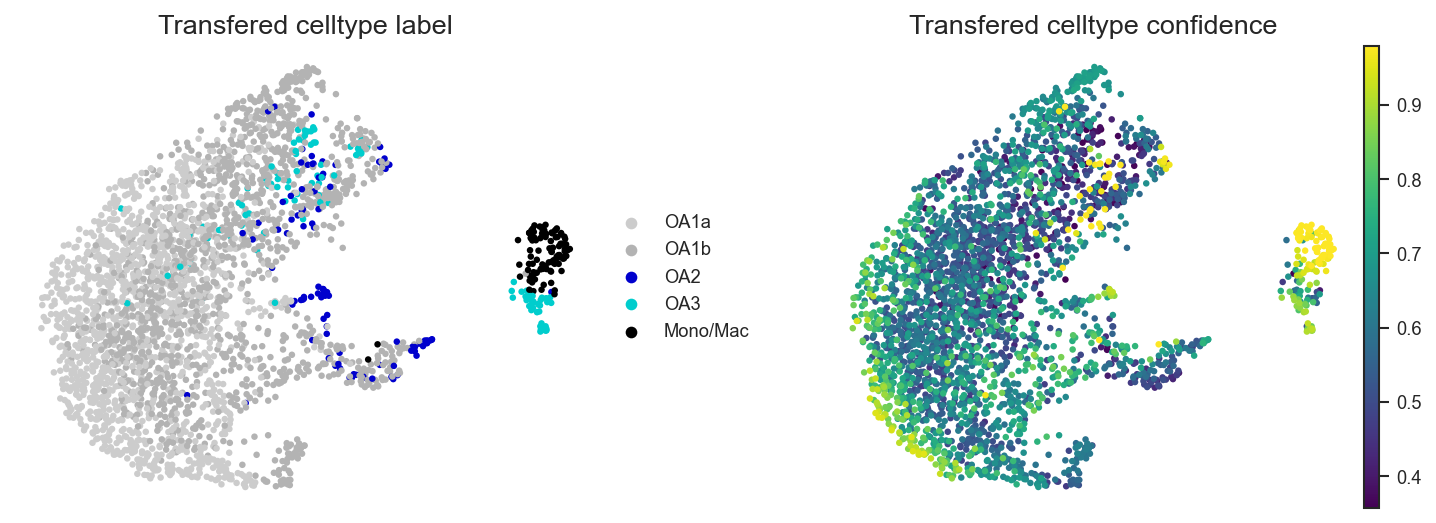

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, parameter in enumerate(['cluster_name', 'cluster_name_confidence']):
    sc.pl.umap(
        scp_glue,
        color=parameter,
        palette=["#CCCCCC", "#B3B3B3", "#0000CD", "#00CDCD", "#000000"],
        frameon=False,
        ax=ax[i],
        show=False,
        title=None,
        cmap='viridis' if parameter == 'cluster_name_confidence' else None,
        vmin='p1',
        vmax='p99',
    )
ax[0].set_title('Transfered celltype label', fontsize=13)
ax[1].set_title('Transfered celltype confidence', fontsize=13)

plt.subplots_adjust(wspace=0.4)
plt.savefig(fig_dir + 'scp_glue_umap_cluster_transfer.pdf', bbox_inches='tight', dpi=300)

In [29]:
rna_glue.obs['domain'] = 'RNA'
scp_glue.obs['domain'] = 'SCP'

In [30]:
adata_joint = sc.concat(
    [rna_glue, scp_glue],
    axis=0,
    join='outer',
    index_unique=None
)

In [31]:
adata_joint

AnnData object with n_obs × n_vars = 17934 × 9907
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'cluster_number', 'tsne_1', 'tsne_2', 'cluster_name', 'age', 'heatmap_idents', 'n_genes', 'domain', 'age_rna', 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter', 'bbknn_leiden_clusters', 'cca_leiden_clusters', 'cluster_name_confidence', 'age_rna_confidence'
    obsm: 'X_glue', 'X_pca', 'X_scANVI', 'X_scVI', 'X_tsne', 'X_umap', 'CCA', 'Combat', 'FastMNN', 'Harmony', 'Liger', 'RPCA', 'Scanorama', 'bbknn_umap', 'scPROTEIN', 'scPROTEIN_PCA', 'scVI_nb', 'scVI_normal'
    layers: 'counts', 'log2_total_normalized', 'log2_total_normalized_fc_nan', 'raw_matrix'

In [32]:
sc.pp.neighbors(adata_joint, use_rep='X_glue', n_neighbors=20)
sc.tl.umap(adata_joint, min_dist=0.3, spread=1.0)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:04)


In [33]:
adata_joint.uns['cluster_name_colors'] = ["#CCCCCC", "#B3B3B3", "#0000CD", "#00CDCD", "#000000"]

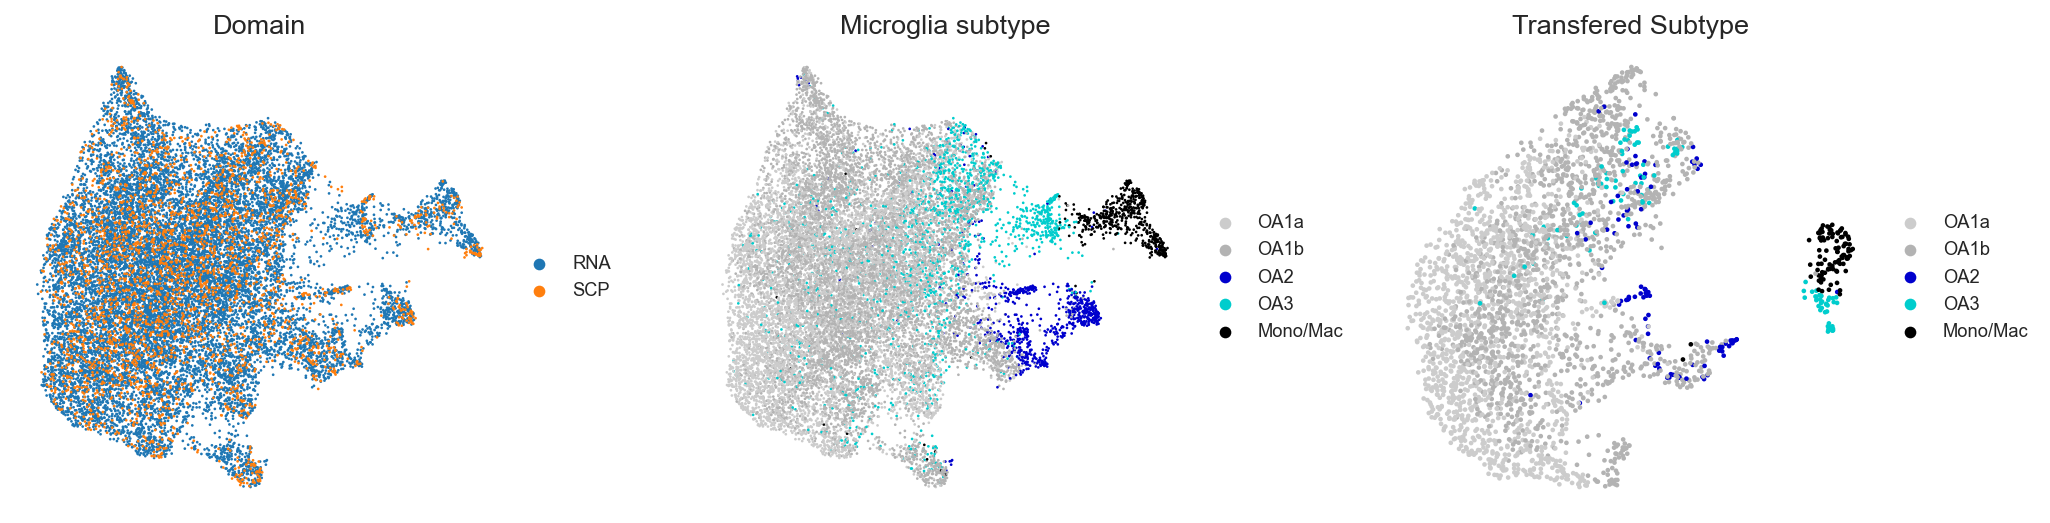

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sc.pl.umap(
    adata_joint,
    color='domain',
    palette=sc.pl.palettes.default_20,
    frameon=False,
    ax=axes[0],
    show=False,
    title=None,
)
axes[0].set_title('Domain', fontsize=13)

sc.pl.umap(
    adata_joint,
    color='cluster_name',
    palette=["#CCCCCC", "#B3B3B3", "#0000CD", "#00CDCD", "#000000"],
    frameon=False,
    ax=axes[1],
    show=False,
    title=None,
)
axes[1].set_title('Microglia subtype', fontsize=13)

sc.pl.umap(
    scp_glue,
    color='cluster_name',
    palette=["#CCCCCC", "#B3B3B3", "#0000CD", "#00CDCD", "#000000"],
    frameon=False,
    ax=axes[2],
    show=False,
    title=None,
    size=20
)
axes[2].set_title('Transfered Subtype', fontsize=13)

plt.subplots_adjust(wspace=0.4)
plt.savefig(fig_dir + 'combined_umap.pdf', bbox_inches='tight', dpi=300)